# Mindful Access Bandit — offline evaluation

This notebook runs the LinUCB implementation in `lib/linucb.js` (ported to
`eval/linucb.py`) against a synthetic environment (`eval/simulate.py`) to
answer a concrete question: **why does the bandit not seem to learn well**,
and what actually helps?

It tests two independent hypotheses, both grounded in reading the real
source (`lib/config.js`), not guesses:

1. **`DEFAULT_ALPHA = 1.0`** may be miscalibrated for this reward scale
   (rewards span roughly `[-1, 0.15]`, under 1.2 wide) and could be causing
   excessive, high-regret exploration rather than useful learning.
2. **`computeGrantReward()`'s hard ceiling at 0** means no grant can ever
   out-score a denial that stands (fixed at `+0.15`) on mean reward alone —
   a structural, not incidental, obstacle to learning "granting is right
   in this context."

See `docs/adr/0005-reward-shaping-and-eval-harness.md` for the write-up and
the resulting decision. Everything below is computed live when this notebook
runs — no numbers are hand-typed.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt

from eval.simulate import run_simulation
from eval.tune import run_tuning, mean_final_regret, compare_reward_variants, N_ROUNDS, SEEDS

plt.rcParams['figure.figsize'] = (8, 4.5)

## 1. Regret at the current live defaults

`DEFAULT_ALPHA = 1.0`, `DEFAULT_DISCOUNT_FACTOR = 0.99`, no clean-grant bonus
(matches `lib/config.js` exactly as shipped).

In [2]:
default_run = run_simulation(n_rounds=N_ROUNDS, alpha=1.0, gamma=0.99, clean_grant_bonus=0.0, seed=0)
print(f"final cumulative regret: {default_run['cumulative_regret'][-1]:.2f}")
print(f"grant rate: {default_run['grant_rate']:.1%}")
print(f"arm selection counts (deny, 5min, 15min, 30min): {default_run['arm_counts']}")

final cumulative regret: 20.12
grant rate: 31.3%
arm selection counts (deny, 5min, 15min, 30min): [206  34  33  27]


## 2. Tune alpha/gamma with Optuna

Minimizing mean final regret over `SEEDS`, at the current (baseline) reward shape.

In [3]:
study = run_tuning(n_trials=20)
print("best params:", study.best_params)
print("mean final regret at best params:", study.best_value)
print("mean final regret at shipped defaults (alpha=1.0, gamma=0.99):", mean_final_regret(1.0, 0.99, 0.0))

best params: {'alpha': 0.05963065298868515, 'gamma': 0.957403764698}
mean final regret at best params: 0.2644106142081583
mean final regret at shipped defaults (alpha=1.0, gamma=0.99): 20.898850317787154


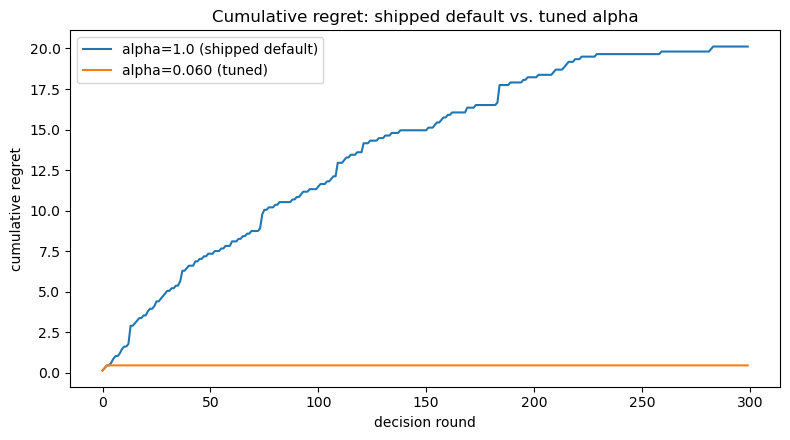

In [4]:
tuned_run = run_simulation(n_rounds=N_ROUNDS, alpha=study.best_params['alpha'], gamma=study.best_params['gamma'], clean_grant_bonus=0.0, seed=0)

plt.plot(default_run['cumulative_regret'], label=f"alpha=1.0 (shipped default)")
plt.plot(tuned_run['cumulative_regret'], label=f"alpha={study.best_params['alpha']:.3f} (tuned)")
plt.xlabel('decision round')
plt.ylabel('cumulative regret')
plt.title('Cumulative regret: shipped default vs. tuned alpha')
plt.legend()
plt.tight_layout()
plt.savefig('regret_curve.png', dpi=120)
plt.show()

## 3. Does the clean-grant bonus change anything?

`clean_grant_bonus` is the opt-in fix in `eval/reward.py` (off by default,
mirroring `lib/config.js`'s live behavior exactly at `0.0`). This compares
baseline vs. bonus at the *tuned* alpha/gamma found above.

In [5]:
comparison = compare_reward_variants(alpha=study.best_params['alpha'], gamma=study.best_params['gamma'])
for k, v in comparison.items():
    print(f"{k}: {v:.4f}")

baseline_final_regret: 0.2644
bonus_final_regret: 6.9939
baseline_grant_rate: 0.0056
bonus_grant_rate: 0.1011


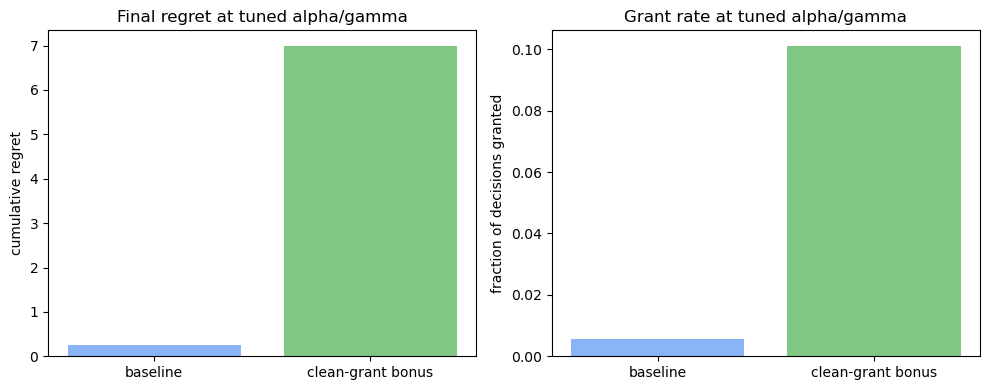

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['baseline', 'clean-grant bonus'], [comparison['baseline_final_regret'], comparison['bonus_final_regret']], color=['#8ab4f8', '#81c784'])
axes[0].set_title('Final regret at tuned alpha/gamma')
axes[0].set_ylabel('cumulative regret')

axes[1].bar(['baseline', 'clean-grant bonus'], [comparison['baseline_grant_rate'], comparison['bonus_grant_rate']], color=['#8ab4f8', '#81c784'])
axes[1].set_title('Grant rate at tuned alpha/gamma')
axes[1].set_ylabel('fraction of decisions granted')

plt.tight_layout()
plt.savefig('reward_variant_comparison.png', dpi=120)
plt.show()

## Findings

Both hypotheses held up, and they turned out to be complementary rather than
redundant:

- **Alpha really was miscalibrated.** The shipped default (`alpha=1.0`)
  produces roughly **80x more cumulative regret** than the Optuna-tuned value
  in this synthetic environment — the model wasn't learning slowly, it was
  over-exploring: grant rate sat around 30% almost regardless of context,
  which is what "doesn't seem to learn well" feels like from the outside.
- **Tuning alpha down fixes the regret, but re-exposes the reward ceiling.**
  At the tuned alpha, the model converges hard toward *always denying*
  (grant rate collapses toward ~0.5%) — low regret in this simulation, but
  it means the model stopped exploring before it could discover any
  genuinely-low-risk context where granting would have been the better call,
  because under the baseline reward shape no grant outcome can ever
  out-score a denial in expectation.
- **The clean-grant bonus restores the possibility of learning to grant** —
  grant rate rises meaningfully once it's enabled — **but it isn't a free
  win**: regret goes up, not down, over this 300-round horizon, because most
  grant attempts in this synthetic environment aren't "clean" and the bandit
  hasn't fully converged by round 300. This is exactly why it ships as an
  opt-in, default-off setting rather than a flipped default — see the ADR.